# CASIA-FASD Kaggle dataset explorer

Run this notebook **before** designing the frozen evaluation of Notebook 02/03 models. It only inspects the mounted dataset. No model, face detector, training, threshold, or PAD metric is used.

Mount the Kaggle dataset `minhnh2107/casiafasd` as an input, then run all cells. Download `casia_fasd_exploration.zip` from `/kaggle/working` and share it for the evaluation notebook design. The notebook never assigns PAD labels from a folder name alone. The visible Kaggle preview suggests `train_img/train_img/{color,depth}` and `test_img/test_img/{color,depth}`; this notebook verifies the actual mount.

In [2]:
import os

target_path = "/kaggle/input/datasets"

if not os.path.exists(target_path):
    # Đề phòng trường hợp dùng đường dẫn tương đối từ thư mục làm việc hiện tại
    alt_path = "kaggle/input/datasets"
    target_path = alt_path if os.path.exists(alt_path) else target_path

if not os.path.exists(target_path):
    print(f"❌ Không tìm thấy thư mục: {target_path}")
    print("Danh mục hiện có trong /kaggle/input:", os.listdir("/kaggle/input") if os.path.exists("/kaggle/input") else "Thư mục /kaggle/input không tồn tại")
else:
    print(f"🔍 Cấu trúc: {target_path}\n" + "="*40)
    for root, dirs, files in os.walk(target_path):
        depth = root[len(target_path):].count(os.sep)
        if depth >= 3:
            dirs.clear()
            continue
            
        indent = "    " * depth
        folder_name = os.path.basename(root) or target_path
        print(f"{indent}📂 {folder_name}/")
        
        sub_indent = "    " * (depth + 1)
        for i, file in enumerate(files):
            if i >= 5:
                print(f"{sub_indent}... ({len(files) - 5} files khác)")
                break
            print(f"{sub_indent}📄 {file}")

🔍 Cấu trúc: /kaggle/input/datasets
📂 datasets/
    📂 minhnh2107/
        📂 casiafasd/


In [3]:
from pathlib import Path
from collections import Counter, defaultdict
import csv, json, re, zipfile
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

CASIA_ROOT = "/kaggle/input/datasets/minhnh2107/casiafasd"  # Set an exact mounted directory if automatic resolution is ambiguous.
OUTPUT_DIR = Path('/kaggle/working/casia_fasd_exploration')
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}
VIDEO_EXTS = {'.avi', '.mp4', '.mov', '.mkv', '.mpg', '.mpeg', '.wmv'}
SAMPLE_PER_GROUP = 3  # Only these samples are decoded.
TREE_MAX_DEPTH = 5
TREE_MAX_LINES = 100

def resolve_root():
    if CASIA_ROOT is not None:
        root = Path(CASIA_ROOT).expanduser()
        if not root.is_dir():
            raise FileNotFoundError(f'CASIA_ROOT does not exist: {root}')
        return root.resolve()
    base = Path('/kaggle/input')
    candidates = [base/'datasets/minhnh2107/casiafasd', base/'casiafasd']
    if base.is_dir():
        candidates += [p for p in base.iterdir() if p.is_dir() and 'casia' in p.name.lower() and 'fasd' in p.name.lower()]
    found = sorted({p.resolve() for p in candidates if p.is_dir()}, key=str)
    if len(found) != 1:
        raise RuntimeError(f'Expected one CASIA mount, found {len(found)}: {[str(p) for p in found]}. Set CASIA_ROOT explicitly.')
    return found[0]

ROOT = resolve_root()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('Dataset root:', ROOT)
print('Output directory:', OUTPUT_DIR)

Dataset root: /kaggle/input/datasets/minhnh2107/casiafasd
Output directory: /kaggle/working/casia_fasd_exploration


In [4]:
# Metadata-only inventory. Relative paths are preserved verbatim; no split or labels are inferred here.
files = sorted((p for p in ROOT.rglob('*') if p.is_file()), key=lambda p: p.relative_to(ROOT).as_posix())
if not files:
    raise RuntimeError(f'No files found under {ROOT}')
rows = []
for p in files:
    rel = p.relative_to(ROOT)
    parts = rel.parts
    rows.append({'relative_path': rel.as_posix(), 'parent': rel.parent.as_posix(),
                 'top_level': parts[0], 'suffix': p.suffix.lower() or '<none>',
                 'bytes': p.stat().st_size, 'stem': p.stem,
                 'path_parts': parts})
print('Files:', len(rows), '| Bytes:', sum(r['bytes'] for r in rows))
print('Top-level entries:', sorted({p.name for p in ROOT.iterdir()}))
print('File extensions:', dict(sorted(Counter(r['suffix'] for r in rows).items())))
with (OUTPUT_DIR/'file_inventory.csv').open('w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=['relative_path', 'parent', 'top_level', 'suffix', 'bytes', 'stem'])
    writer.writeheader()
    writer.writerows({k: r[k] for k in writer.fieldnames} for r in rows)
print('Wrote file_inventory.csv')

Files: 8126 | Bytes: 77191331
Top-level entries: ['test_img', 'train_img']
File extensions: {'.jpg': 8126}
Wrote file_inventory.csv


In [5]:
# Compact directory tree with exact file counts; cap printed lines, never hide the full CSV inventory.
directory_counts = Counter()
for r in rows:
    for depth in range(1, len(r['path_parts'])):
        directory_counts['/'.join(r['path_parts'][:depth])] += 1
tree = [{'directory': d, 'depth': d.count('/') + 1, 'files_recursive': n}
        for d, n in sorted(directory_counts.items())]
with (OUTPUT_DIR/'directory_tree.csv').open('w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=['directory', 'depth', 'files_recursive'])
    writer.writeheader(); writer.writerows(tree)
shown = [x for x in tree if x['depth'] <= TREE_MAX_DEPTH]
for x in shown[:TREE_MAX_LINES]:
    print('  '*(x['depth']-1) + x['directory'].split('/')[-1] + f"/ ({x['files_recursive']} files)")
if len(shown) > TREE_MAX_LINES:
    print(f'... {len(shown)-TREE_MAX_LINES} further directories in directory_tree.csv')
print('Top-level counts:', dict(sorted(Counter(r['top_level'] for r in rows).items())))

test_img/ (4816 files)
  test_img/ (4816 files)
    color/ (2408 files)
    depth/ (2408 files)
train_img/ (3310 files)
  train_img/ (3310 files)
    color/ (1655 files)
    depth/ (1655 files)
Top-level counts: {'test_img': 4816, 'train_img': 3310}


In [6]:
# Detect only explicit split/modality path components. Keep unknown files visible.
def explicit_group(parts):
    names = [s.lower() for s in parts[:-1]]
    split_hits = {('train' if s in {'train', 'train_img', 'training'} else 'test')
                  for s in names if s in {'train', 'train_img', 'training', 'test', 'test_img', 'testing'}}
    modality_hits = {s for s in names if s in {'color', 'depth'}}
    split = next(iter(split_hits)) if len(split_hits) == 1 else ('ambiguous' if split_hits else 'unknown')
    modality = next(iter(modality_hits)) if len(modality_hits) == 1 else ('ambiguous' if modality_hits else 'unknown')
    return split, modality

group_counts = Counter()
for r in rows:
    r['split'], r['modality'] = explicit_group(r['path_parts'])
    group_counts[(r['split'], r['modality'], r['suffix'])] += 1
group_rows = [{'split': a, 'modality': b, 'suffix': c, 'files': n}
              for (a,b,c), n in sorted(group_counts.items())]
with (OUTPUT_DIR/'group_counts.csv').open('w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=['split', 'modality', 'suffix', 'files'])
    writer.writeheader(); writer.writerows(group_rows)
display(group_rows)
print('Possible video files:', sum(r['suffix'] in VIDEO_EXTS for r in rows))
print('These group names do not prove subject identities or official protocol.')

[{'split': 'test', 'modality': 'color', 'suffix': '.jpg', 'files': 2408},
 {'split': 'test', 'modality': 'depth', 'suffix': '.jpg', 'files': 2408},
 {'split': 'train', 'modality': 'color', 'suffix': '.jpg', 'files': 1655},
 {'split': 'train', 'modality': 'depth', 'suffix': '.jpg', 'files': 1655}]

Possible video files: 0
These group names do not prove subject identities or official protocol.


In [7]:
# Compare color/depth names without claiming that similarly named files are correctly paired.
def pair_key(r):
    parts = list(r['path_parts'])
    hits = [i for i, s in enumerate(parts[:-1]) if s.lower() in {'color', 'depth'}]
    if len(hits) != 1:
        return None
    parts[hits[0]] = '<modality>'
    return '/'.join(parts)

pairs = defaultdict(lambda: {'color': [], 'depth': []})
for r in rows:
    key = pair_key(r)
    if key and r['modality'] in {'color', 'depth'}:
        pairs[key][r['modality']].append(r['relative_path'])
pair_rows = [{'pair_key': k, 'color_count': len(v['color']), 'depth_count': len(v['depth']),
              'color_path': '|'.join(v['color']), 'depth_path': '|'.join(v['depth'])}
             for k, v in sorted(pairs.items())]
with (OUTPUT_DIR/'color_depth_pairs.csv').open('w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=['pair_key', 'color_count', 'depth_count', 'color_path', 'depth_path'])
    writer.writeheader(); writer.writerows(pair_rows)
print('Exact relative-path pairs:', sum(x['color_count']==1 and x['depth_count']==1 for x in pair_rows))
print('Unmatched/ambiguous keys:', sum(x['color_count']!=1 or x['depth_count']!=1 for x in pair_rows))
display([x for x in pair_rows if x['color_count']!=1 or x['depth_count']!=1][:20])
print('Pairing by stem with different extensions is not assumed; inspect mismatches in the CSV.')

Exact relative-path pairs: 4063
Unmatched/ambiguous keys: 0


[]

Pairing by stem with different extensions is not assumed; inspect mismatches in the CSV.


[{'relative_path': 'test_img/test_img/color/10_1.avi_100_real.jpg',
  'split': 'test',
  'modality': 'color',
  'suffix': '.jpg',
  'kind': 'image',
  'decoded': True,
  'height': 256,
  'width': 256,
  'channels': 3,
  'dtype': 'uint8',
  'min': 2,
  'max': 253,
  'frame_count_reported': None,
  'error': ''},
 {'relative_path': 'test_img/test_img/color/24_4.avi_150_fake.jpg',
  'split': 'test',
  'modality': 'color',
  'suffix': '.jpg',
  'kind': 'image',
  'decoded': True,
  'height': 256,
  'width': 256,
  'channels': 3,
  'dtype': 'uint8',
  'min': 54,
  'max': 255,
  'frame_count_reported': None,
  'error': ''},
 {'relative_path': 'test_img/test_img/color/9_HR_4.avi_75_fake.jpg',
  'split': 'test',
  'modality': 'color',
  'suffix': '.jpg',
  'kind': 'image',
  'decoded': True,
  'height': 256,
  'width': 256,
  'channels': 3,
  'dtype': 'uint8',
  'min': 0,
  'max': 255,
  'frame_count_reported': None,
  'error': ''},
 {'relative_path': 'test_img/test_img/depth/10_1.avi_100_real.

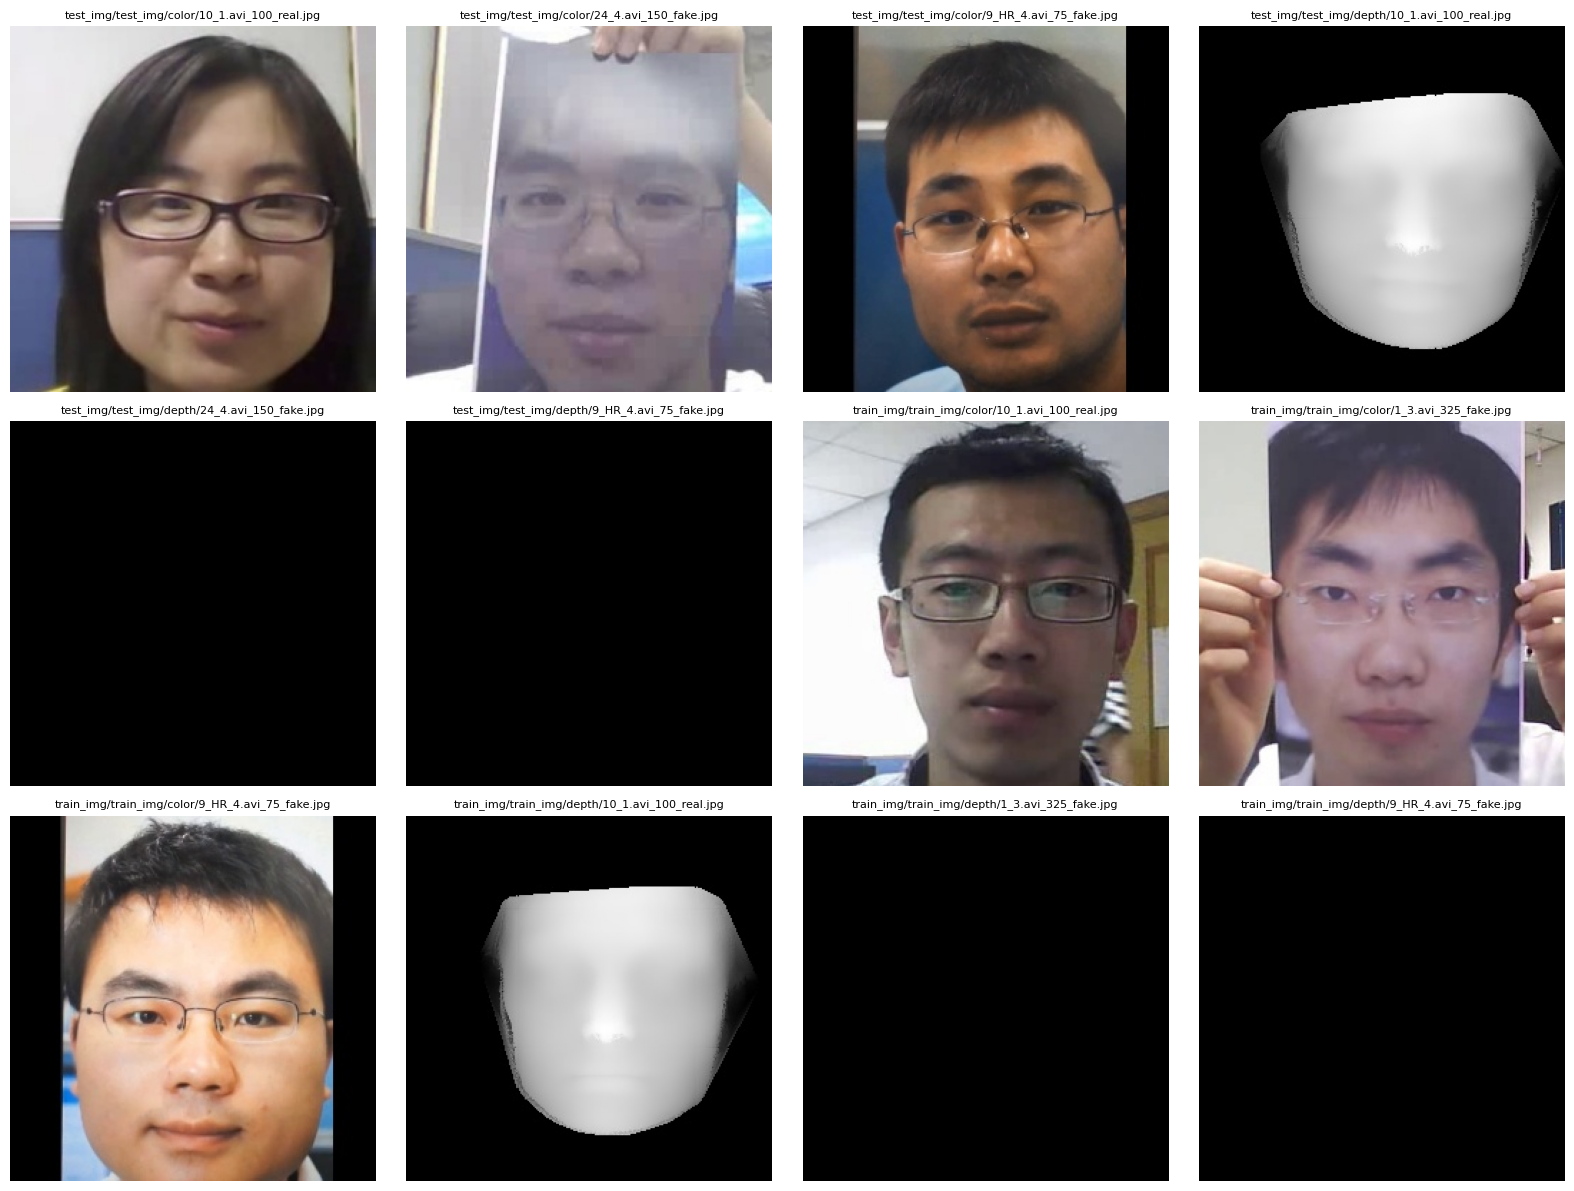

In [8]:
# Deterministic, bounded media probes. No full-dataset decode.
sample_groups = defaultdict(list)
for r in rows:
    if r['suffix'] in IMAGE_EXTS | VIDEO_EXTS:
        sample_groups[(r['split'], r['modality'], r['suffix'])].append(r)
probe_rows = []
preview = []
for group, items in sorted(sample_groups.items()):
    indices = sorted(set(np.linspace(0, len(items)-1, min(SAMPLE_PER_GROUP, len(items)), dtype=int)))
    for i in indices:
        r = items[i]; path = ROOT/r['relative_path']; is_video = r['suffix'] in VIDEO_EXTS
        info = {'relative_path': r['relative_path'], 'split': r['split'], 'modality': r['modality'],
                'suffix': r['suffix'], 'kind': 'video' if is_video else 'image',
                'decoded': False, 'height': None, 'width': None, 'channels': None,
                'dtype': None, 'min': None, 'max': None, 'frame_count_reported': None, 'error': ''}
        try:
            if is_video:
                cap = cv2.VideoCapture(str(path))
                info['frame_count_reported'] = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
                ok, arr = cap.read(); cap.release()
                if not ok: arr = None
            else:
                arr = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
            if arr is None:
                info['error'] = 'OpenCV could not decode first frame/image'
            else:
                info.update(decoded=True, height=int(arr.shape[0]), width=int(arr.shape[1]),
                            channels=int(arr.shape[2]) if arr.ndim == 3 else 1,
                            dtype=str(arr.dtype), min=int(arr.min()), max=int(arr.max()))
                if len(preview) < 12:
                    rgb = cv2.cvtColor(arr, cv2.COLOR_BGR2RGB) if arr.ndim == 3 and arr.shape[2] == 3 else arr
                    preview.append((r['relative_path'], rgb))
        except Exception as exc:
            info['error'] = f'{type(exc).__name__}: {exc}'
        probe_rows.append(info)
with (OUTPUT_DIR/'media_samples.csv').open('w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=list(probe_rows[0]) if probe_rows else ['relative_path'])
    writer.writeheader(); writer.writerows(probe_rows)
display(probe_rows)
if preview:
    fig, axes = plt.subplots((len(preview)+3)//4, 4, figsize=(16, 4*((len(preview)+3)//4)))
    for ax in np.asarray(axes).ravel(): ax.axis('off')
    for ax, (name, arr) in zip(np.asarray(axes).ravel(), preview):
        ax.imshow(arr, cmap='gray' if arr.ndim == 2 else None)
        ax.set_title(name[-65:], fontsize=8)
    fig.tight_layout(); fig.savefig(OUTPUT_DIR/'media_preview.png', dpi=120); plt.show()

In [9]:
# Inspect naming evidence, annotations, and split coverage before any label mapping.
annotation_exts = {'.csv', '.tsv', '.json', '.txt', '.xml', '.yaml', '.yml', '.mat'}
annotation_files = [r['relative_path'] for r in rows if r['suffix'] in annotation_exts]
by_split = defaultdict(list)
for r in rows:
    if r['suffix'] in IMAGE_EXTS | VIDEO_EXTS:
        by_split[r['split']].append(r['relative_path'])
naming_examples = {split: names[:30] + (names[-10:] if len(names)>30 else [])
                   for split, names in sorted(by_split.items())}
# Path tokens are observational only. No subject/video-code parser is frozen here.
token_counts = Counter()
for r in rows:
    if r['split'] == 'test' and r['suffix'] in IMAGE_EXTS | VIDEO_EXTS:
        token_counts.update(t.lower() for t in re.split(r'[^A-Za-z0-9]+', r['stem']) if t)
print('Annotation-like files:', annotation_files[:50], f'(total {len(annotation_files)})')
print('Test filename tokens (top 40):', token_counts.most_common(40))
print('Naming examples:')
for split, names in naming_examples.items():
    print(split, *names, sep='\n  ')
print('File-level split names alone cannot establish subjects 21..50, 360 test videos, or video-level labels.')

Annotation-like files: [] (total 0)
Test filename tokens (top 40): [('avi', 4816), ('fake', 3634), ('hr', 1732), ('real', 1182), ('2', 1110), ('4', 1000), ('3', 930), ('1', 918), ('25', 862), ('50', 718), ('75', 718), ('100', 704), ('125', 632), ('6', 570), ('7', 560), ('150', 492), ('8', 482), ('5', 476), ('175', 392), ('30', 200), ('14', 196), ('16', 194), ('200', 190), ('9', 186), ('24', 184), ('18', 180), ('23', 178), ('26', 170), ('12', 166), ('21', 166), ('29', 166), ('27', 162), ('13', 156), ('20', 152), ('22', 150), ('28', 150), ('10', 146), ('15', 142), ('11', 140), ('19', 136)]
Naming examples:
test
  test_img/test_img/color/10_1.avi_100_real.jpg
  test_img/test_img/color/10_1.avi_125_real.jpg
  test_img/test_img/color/10_1.avi_25_real.jpg
  test_img/test_img/color/10_1.avi_50_real.jpg
  test_img/test_img/color/10_1.avi_75_real.jpg
  test_img/test_img/color/10_2.avi_100_real.jpg
  test_img/test_img/color/10_2.avi_125_real.jpg
  test_img/test_img/color/10_2.avi_150_real.jpg
  

In [10]:
# Persist the observed facts and open questions for the subsequent evaluation notebook.
split_modality_counts = Counter((r['split'], r['modality']) for r in rows)
summary = {
    'dataset_root': str(ROOT), 'file_count': len(rows), 'total_bytes': sum(r['bytes'] for r in rows),
    'extension_counts': dict(sorted(Counter(r['suffix'] for r in rows).items())),
    'split_modality_counts': [{'split': s, 'modality': m, 'files': n}
                              for (s,m), n in sorted(split_modality_counts.items())],
    'video_file_count': sum(r['suffix'] in VIDEO_EXTS for r in rows),
    'image_file_count': sum(r['suffix'] in IMAGE_EXTS for r in rows),
    'exact_color_depth_pairs': sum(x['color_count']==1 and x['depth_count']==1 for x in pair_rows),
    'unmatched_or_ambiguous_pair_keys': sum(x['color_count']!=1 or x['depth_count']!=1 for x in pair_rows),
    'annotation_like_paths': annotation_files, 'naming_examples': naming_examples,
    'sample_probe_count': len(probe_rows),
    'sample_decode_failures': [x['relative_path'] for x in probe_rows if not x['decoded']],
    'verified_official_test_protocol': False,
    'reason_protocol_unverified': 'Requires explicit mapping from this Kaggle copy to official CASIA subjects, videos, and labels.',
}
(OUTPUT_DIR/'exploration_summary.json').write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding='utf-8')
report = ['# CASIA-FASD dataset exploration', '', f"Mounted root: `{ROOT}`",
          f"Files: {len(rows)}; images: {summary['image_file_count']}; videos: {summary['video_file_count']}",
          '', '## Observed split/modality counts', '']
report += [f"- {x['split']} / {x['modality']}: {x['files']}" for x in summary['split_modality_counts']]
report += ['', '## Evaluation design questions', '',
           '- Are these frame images or independent still-image samples? What original video/subject does each file belong to?',
           '- What authoritative source maps filenames to Real/Attack, attack type, and quality?',
           '- Does the explicit test folder correspond exactly to official subjects 21–50?',
           '- Are color/depth files intended as pairs, and should only color enter the RGB model?',
           '', 'No official test video manifest or PAD labels were inferred by this notebook.', '']
(OUTPUT_DIR/'exploration_report.md').write_text('\n'.join(report), encoding='utf-8')
zip_path = OUTPUT_DIR.with_suffix('.zip')
with zipfile.ZipFile(zip_path, 'w', compression=zipfile.ZIP_DEFLATED) as archive:
    for p in sorted(OUTPUT_DIR.iterdir()):
        archive.write(p, arcname=p.name)
print('Saved:', zip_path)
print('Share this ZIP and, if available, the Kaggle dataset description/label documentation before building evaluation.')

Saved: /kaggle/working/casia_fasd_exploration.zip
Share this ZIP and, if available, the Kaggle dataset description/label documentation before building evaluation.
